In [1]:
import seaborn as sns
import numpy as np

# query

Provide the python code for visualizing the genes expression values through heatmap with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset.

# old

In [2]:
import scanpy as sc

# First, you will need to load the dataset. If you do not have it,
# you can download and load it directly from the scanpy datasets.
adata = sc.datasets.pbmc3k_processed()
print(adata)

# Normally at this stage, the data should already be preprocessed,
# so we can directly use the data for visualization.

# Select a subset of genes for visualization, for example
genes_of_interest = ['IL7R', 'CD79A', 'CD3D', 'CD14', 'LYZ']

# Ensure the genes are in the expression matrix
adata_subset = adata[:, adata.var_names.isin(genes_of_interest)]
print(adata_subset)

# Create the heatmap for the selected genes.
sc.pl.heatmap(adata_subset, var_names=genes_of_interest, groupby='louvain', cmap='viridis', dendrogram=True)

# save plot if needed
# plt.savefig('heatmap.png')

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
View of AnnData object with n_obs × n_vars = 2638 × 1
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


ValueError: Distance matrix 'X' must be symmetric.

## sol 1: investigation

### it makes no sense of genes_of_interest since only one gene is left. This is because gpt4 guess a list of genes, and luckily there's one gene in this list also in data. A more reasonable approach is 1) let bioma access gene columns to select a reasonable number of genes, and 2) let users tell bioma which genes he wants to know.

In [4]:
import scanpy as sc

# First, you will need to load the dataset. If you do not have it,
# you can download and load it directly from the scanpy datasets.
adata = sc.datasets.pbmc3k_processed()

### lets use some genes

In [5]:
adata.var_names

Index(['TNFRSF4', 'CPSF3L', 'ATAD3C', 'C1orf86', 'RER1', 'TNFRSF25', 'TNFRSF9',
       'CTNNBIP1', 'SRM', 'UBIAD1',
       ...
       'DSCR3', 'BRWD1', 'BACE2', 'SIK1', 'C21orf33', 'ICOSLG', 'SUMO3',
       'SLC19A1', 'S100B', 'PRMT2'],
      dtype='object', name='index', length=1838)

In [6]:
adata_subset = adata[:, adata.var_names.isin(['TNFRSF4', 'CPSF3L', 'ATAD3C', 'C1orf86', 'RER1'])]

### note that this codes assume that 'louvain' exists in data. It is an coincidence that data has this information, since gpt4 cannot access data and don't know data has it or not.

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:193: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


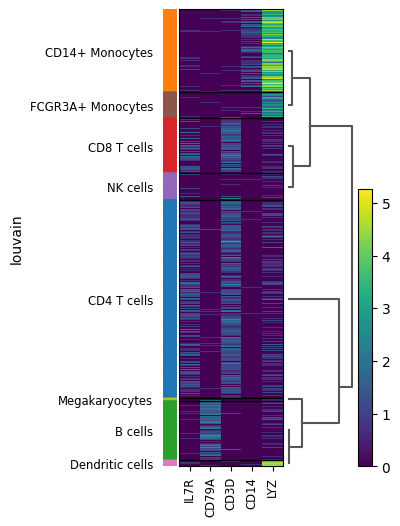

In [8]:
sc.pl.heatmap(adata_subset, var_names=genes_of_interest, groupby='louvain', cmap='viridis', dendrogram=True)

### note that heatmap requires sc.tl.dendrogram be executed in advance, but not mandatory. If not run before, it will automatically run dendrogram with default args. This is not a big problem, but could give more customization to users if dendrogram is executed in advance. Bioma can refer to warning to fix it.

In [14]:
sc.tl.dendrogram(adata_subset, groupby='louvain')

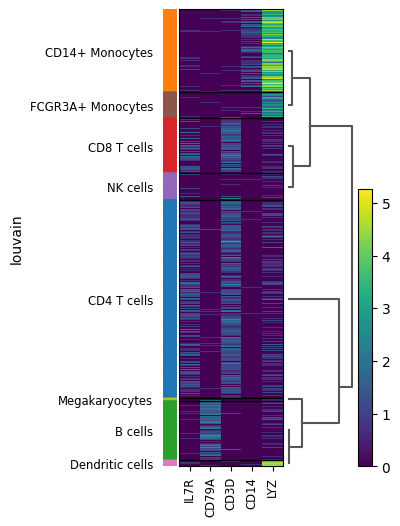

In [15]:
sc.pl.heatmap(adata_subset, var_names=genes_of_interest, groupby='louvain', cmap='viridis', dendrogram=True)

### great! it works. Below is corrected codes.

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:193: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


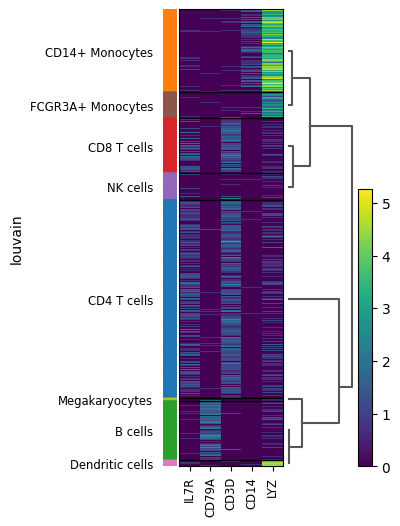

In [17]:
import scanpy as sc

# First, you will need to load the dataset. If you do not have it,
# you can download and load it directly from the scanpy datasets.
adata = sc.datasets.pbmc3k_processed()

adata_subset = adata[:, adata.var_names.isin(['TNFRSF4', 'CPSF3L', 'ATAD3C', 'C1orf86', 'RER1'])]
sc.tl.dendrogram(adata_subset, groupby='louvain')
sc.pl.heatmap(adata_subset, var_names=genes_of_interest, groupby='louvain', cmap='viridis', dendrogram=True)

# new

In [18]:
import scanpy as sc

# Step 1: Load the PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Step 2: Preprocess the dataset (if not already preprocessed)
# Normalize (this dataset is already normalized and log-transformed as per Scanpy's dataset description)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify highly variable genes (already done in pbmc3k_processed, but here as a template)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Step 3: PCA
sc.tl.pca(adata, svd_solver='arpack')

# Step 4: Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Step 5: Run clustering (e.g., Louvain)
sc.tl.louvain(adata)

# Step 6: Run UMAP (for visualization purposes)
sc.tl.umap(adata)

# Step 7: Find marker genes
sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')

# Step 8: Plotting Heatmap of the top 20 marker genes per cluster
sc.pl.heatmap(adata, var_names=adata.uns['rank_genes_groups']['names'][0:20], groupby='louvain', cmap='viridis', dendrogram=True)

# Additional: Plot UMAP to visualize the clusters
sc.pl.umap(adata, color='louvain', title='UMAP projection of the PBMC3k dataset', frameon=False)

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


TypeError: putmask: first argument must be an array

### like problem we observe before, first remove those unnecessary preprocessing. 

In [2]:
import scanpy as sc

# Step 1: Load the PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Step 2: Preprocess the dataset (if not already preprocessed)
# Normalize (this dataset is already normalized and log-transformed as per Scanpy's dataset description)
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# Identify highly variable genes (already done in pbmc3k_processed, but here as a template)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Step 3: PCA
sc.tl.pca(adata, svd_solver='arpack')

# Step 4: Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Step 5: Run clustering (e.g., Louvain)
sc.tl.louvain(adata)

# Step 6: Run UMAP (for visualization purposes)
sc.tl.umap(adata)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### note that according to doc, rank_genes_groups() expect log data. so log preprocessing needs to be conducted in advance.

In [3]:
# Step 7: Find marker genes
sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')

In [39]:
# Step 8: Plotting Heatmap of the top 20 marker genes per cluster
sc.pl.heatmap(adata, var_names=adata.uns['rank_genes_groups']['names'][0:20], groupby='louvain', cmap='viridis', dendrogram=True)

TypeError: unhashable type: 'writeable void-scalar'

### 1) var_names has to be a list, cannot be a set. 2) var_names needs to be a subset of adata.var_names

### gpt4 wants to show gene expression values of differentially expressed genes ("Step 8: Plotting Heatmap of the top 20 marker genes per cluster"). But codes ain't work like that: var_names=adata.uns['rank_genes_groups']['names'][0:20]

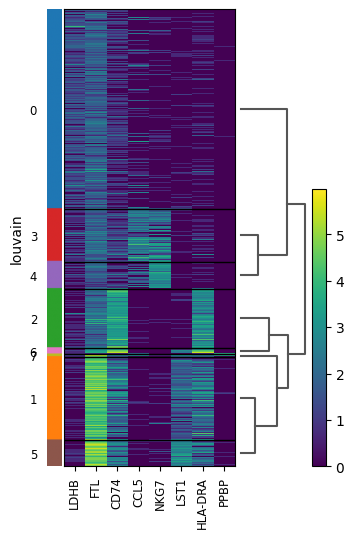

In [37]:
sc.pl.heatmap(adata, var_names=list(adata.uns['rank_genes_groups']['names'][0]), 
              groupby='louvain', cmap='viridis', dendrogram=True)

### ATTENTION: I found a problem - gpt4 sometimes would use its own creativity to add some unnecessary code lines to implement more functions. assume that to achieve the target of query, we have a minimum scope of codes (MSC). If we add some functions, such as more visualizations or selecting differentially expressed genes like above (rather than simply and randomly selecting some genes, which should be the simplest and most fundamental way of "gene selection"), we have MSC+functions, which still follow the query. However, this approach brings higher possibility of bugs.

### ATTENTION: In other words, we should let bioma generate MSC, and add functions by communicating with users.